# Mutual Fund Data Analysis (EDA)

## Bluestock Internship Project

### Objective

This notebook performs Exploratory Data Analysis (EDA) on Mutual Fund datasets. The analysis includes:

- NAV Trend Analysis
- AUM Growth Analysis
- SIP Inflow Analysis
- Category-wise Inflow Analysis
- Investor Demographics
- Geographic Distribution
- Folio Growth
- Correlation Analysis
- Sector Allocation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load datasets

fund = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/clean_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")
transactions = pd.read_csv("../data/processed/clean_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
print("Fund Master:", fund.shape)
print("NAV History:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folio:", folio.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Portfolio:", portfolio.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Portfolio: (322, 8)


# 1. NAV Trend Analysis (2022–2026)

This visualization shows the daily NAV movement of all mutual fund schemes from 2022 to 2026. Green highlights represent the 2023 bull run, while red highlights indicate the 2024 market correction.

In [4]:
# NAV Trend Analysis

import plotly.express as px

# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

# Convert AMFI code to string for legend
nav["amfi_code"] = nav["amfi_code"].astype(str)

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "amfi_code": "AMFI Code"
    }
)

# Highlight Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    annotation_text="2024 Correction",
    annotation_position="top left"
)

fig.update_layout(
    width=1200,
    height=600,
    legend_title="Scheme",
    template="plotly_white"
)

fig.show()

In [5]:
fig.write_html("../reports/charts/nav_trend.html")

# 2. AUM Growth Analysis

This chart compares the Assets Under Management (AUM) of different fund houses from 2022 to 2025 and highlights SBI Mutual Fund's market dominance.

In [6]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


In [7]:
# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Keep only 2022-2025
aum_filtered = aum[aum["year"].between(2022, 2025)]

print(aum_filtered.head())

        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


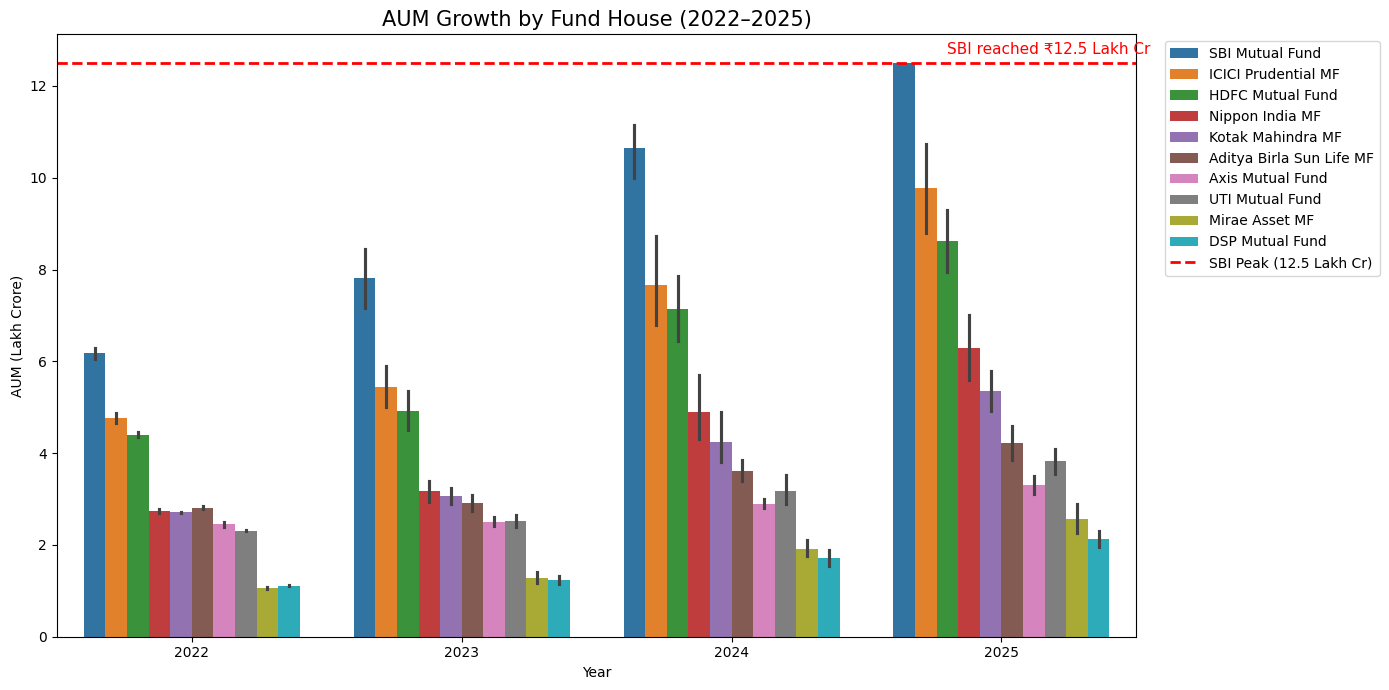

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert date and extract year
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

# Filter years
aum_filtered = aum[(aum["year"] >= 2022) & (aum["year"] <= 2025)]

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum_filtered,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

# Highlight SBI Peak
plt.axhline(
    y=12.5,
    color="red",
    linestyle="--",
    linewidth=2,
    label="SBI Peak (12.5 Lakh Cr)"
)

plt.text(
    2.8,
    12.7,
    "SBI reached ₹12.5 Lakh Cr",
    color="red",
    fontsize=11
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=15)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()

plt.savefig("../reports/charts/aum_growth.png", dpi=300)

plt.show()

In [11]:
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')


# 3. Monthly SIP Inflow Trend (2022–2025)

This chart shows the monthly SIP inflow trend from January 2022 to December 2025 and highlights the all-time high SIP inflow of ₹31,002 Crore recorded in December 2025.

In [12]:
import plotly.express as px

# Convert month column
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)"
)

# Find highest SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f'₹{max_row["sip_inflow_crore"]:,} Cr<br>All-Time High',
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Crore)",
    template="plotly_white",
    width=1200,
    height=600
)

fig.show()

In [13]:
fig.write_html("../reports/charts/sip_inflow.html")

In [14]:
print(category.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='object')


# 4. Category-wise Net Inflow Heatmap

This heatmap shows the monthly net inflow across different mutual fund categories. Darker colors represent higher inflows.

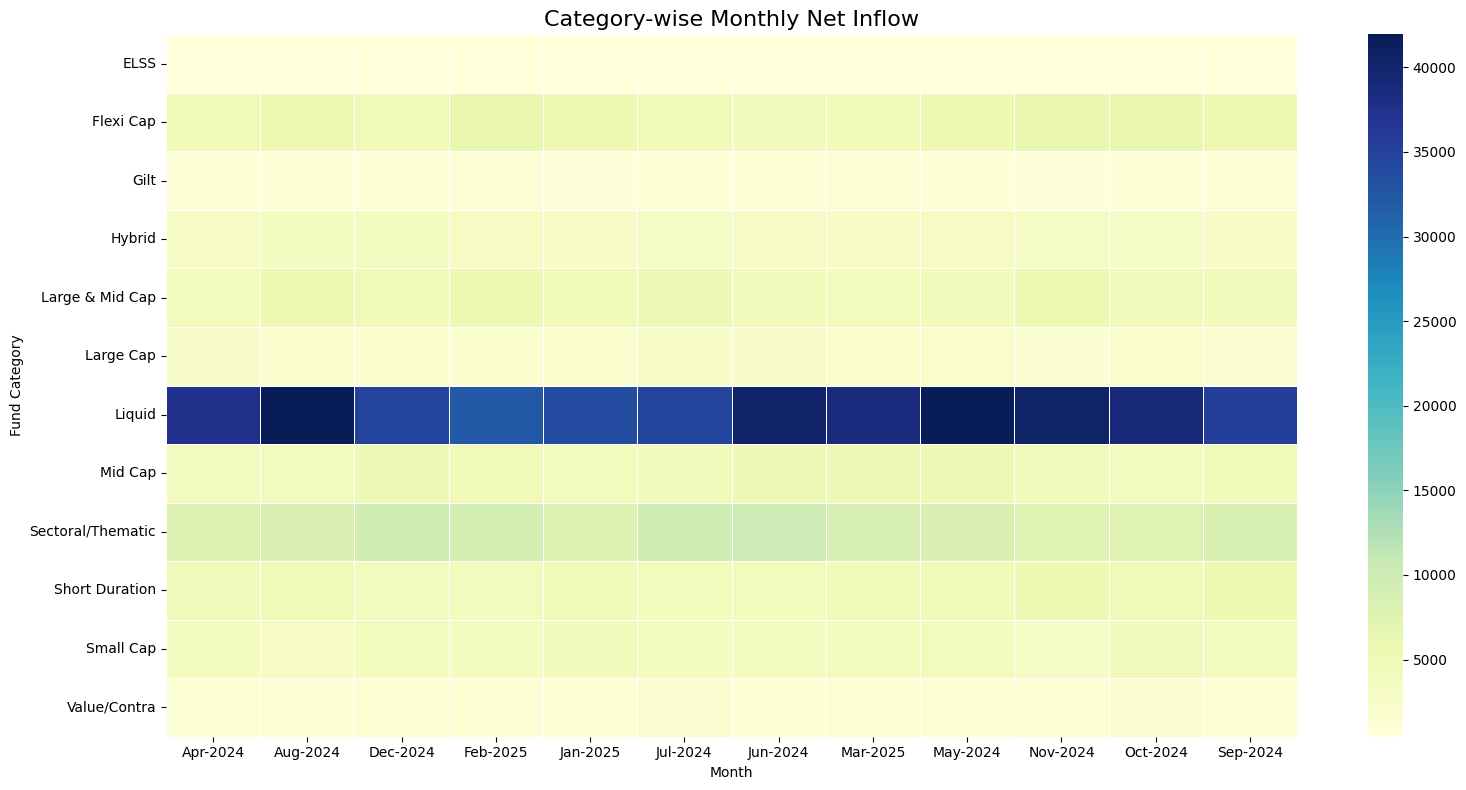

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Convert month to readable format
category["Month"] = category["month"].dt.strftime("%b-%Y")

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="Month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=False
)

plt.title("Category-wise Monthly Net Inflow", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig("../reports/charts/category_heatmap.png", dpi=300)

plt.show()

In [16]:
print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


# 5. Age Group Distribution

This pie chart shows the distribution of investors across different age groups.

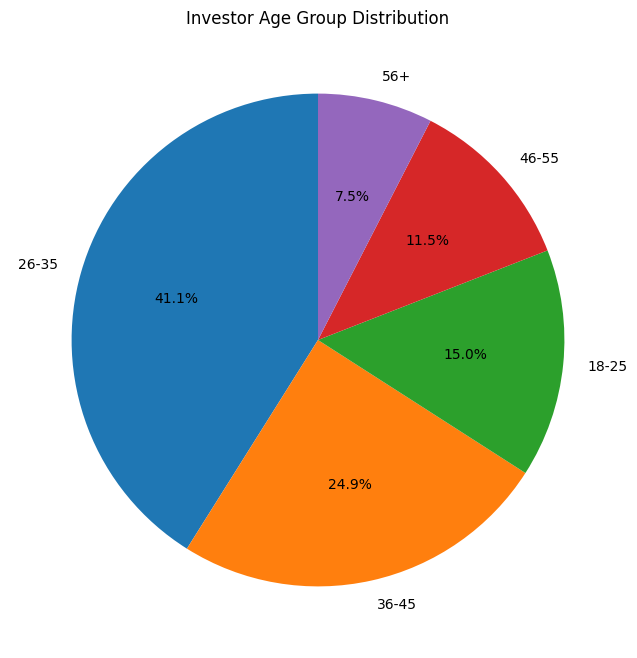

In [17]:
import matplotlib.pyplot as plt

age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig("../reports/charts/age_group_distribution.png", dpi=300)

plt.show()

# 6. SIP Amount Distribution by Age Group

This box plot compares SIP investment amounts across different age groups.

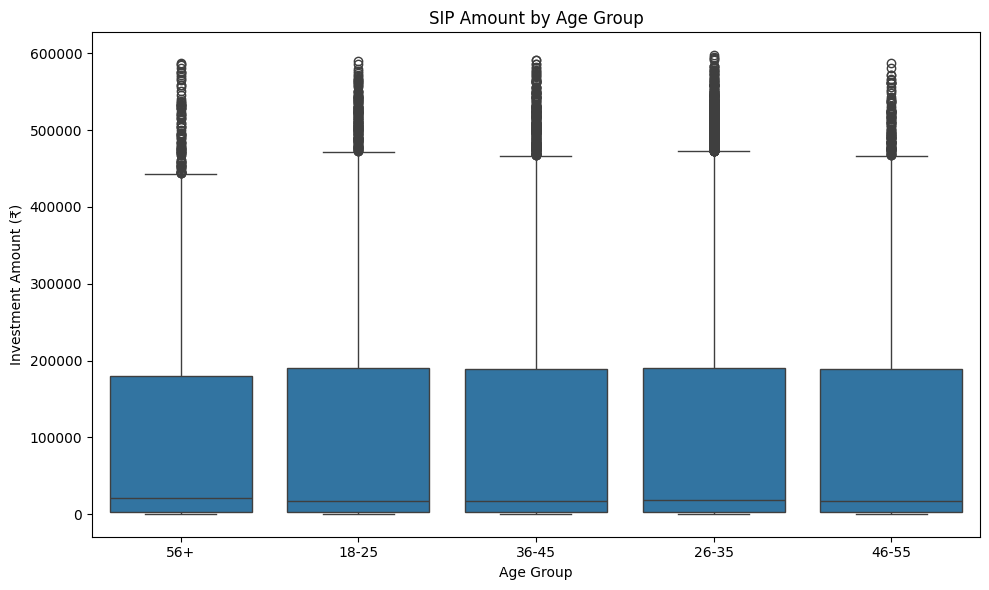

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()

plt.savefig("../reports/charts/sip_boxplot_age.png", dpi=300)

plt.show()

# 7. Gender Distribution

This chart shows the gender-wise distribution of mutual fund investors.

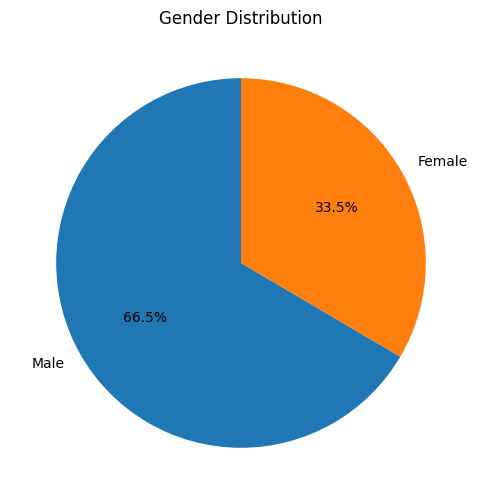

In [19]:
gender = transactions["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.savefig("../reports/charts/gender_distribution.png", dpi=300)

plt.show()

# 8. SIP Amount by State

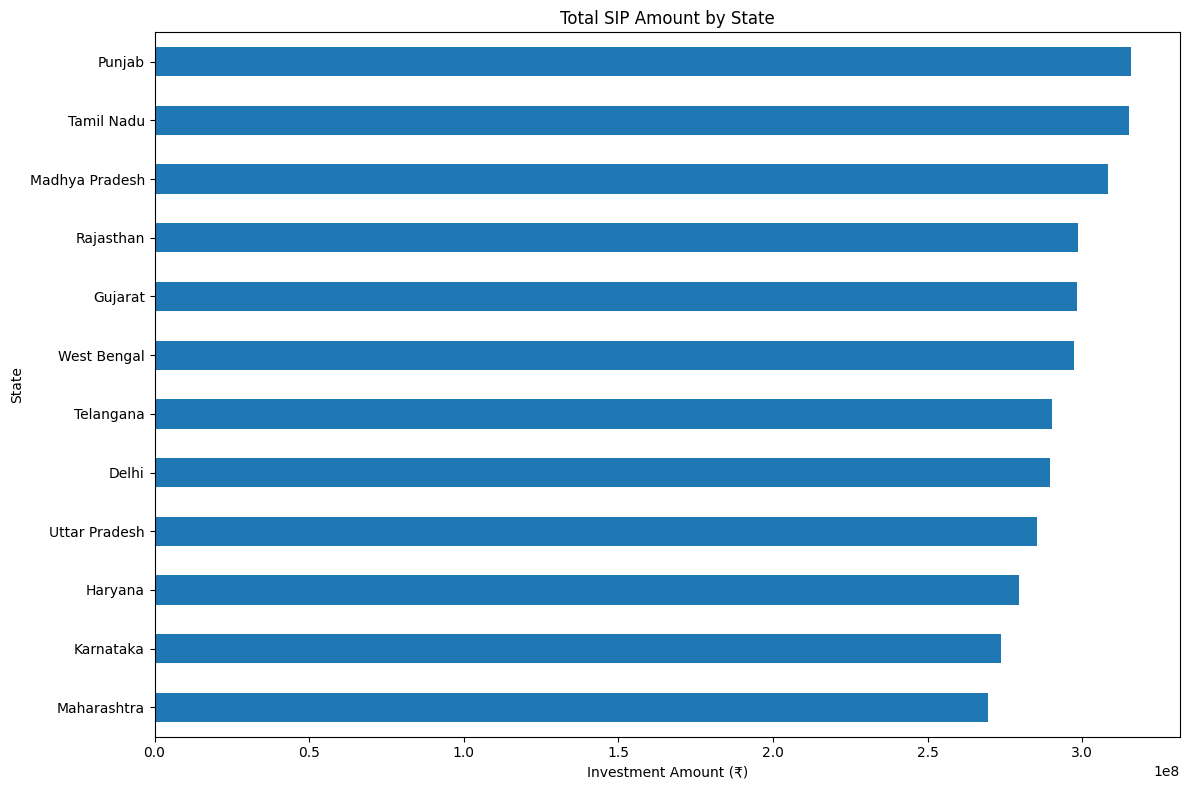

In [20]:
state = transactions.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(12,8))

state.plot(kind="barh")

plt.title("Total SIP Amount by State")
plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig("../reports/charts/state_distribution.png", dpi=300)

plt.show()

# 9. T30 vs B30 Distribution

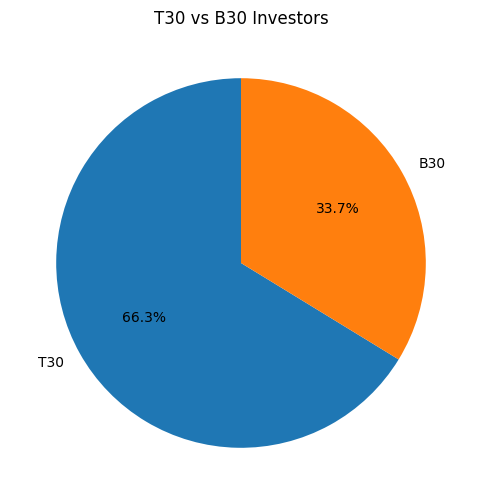

In [21]:
tier = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investors")

plt.savefig("../reports/charts/t30_b30.png", dpi=300)

plt.show()

In [22]:
print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')


# 10. Folio Count Growth

This chart shows the growth of mutual fund folios from January 2022 to December 2025.

In [23]:
import plotly.express as px

# Convert month column
folio["month"] = pd.to_datetime(folio["month"])

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth in Total Mutual Fund Folios (2022–2025)"
)

# Mark first point
fig.add_annotation(
    x=folio["month"].iloc[0],
    y=folio["total_folios_crore"].iloc[0],
    text="Jan 2022: 13.26 Cr",
    showarrow=True
)

# Mark last point
fig.add_annotation(
    x=folio["month"].iloc[-1],
    y=folio["total_folios_crore"].iloc[-1],
    text="Dec 2025: 26.12 Cr",
    showarrow=True
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)"
)

fig.show()

fig.write_html("../reports/charts/folio_growth.html")

# 11. Daily returns

In [28]:
# Calculate daily returns
returns = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = returns.pct_change()

# Select first 10 funds
returns = returns.iloc[:, :10]

corr = returns.corr()

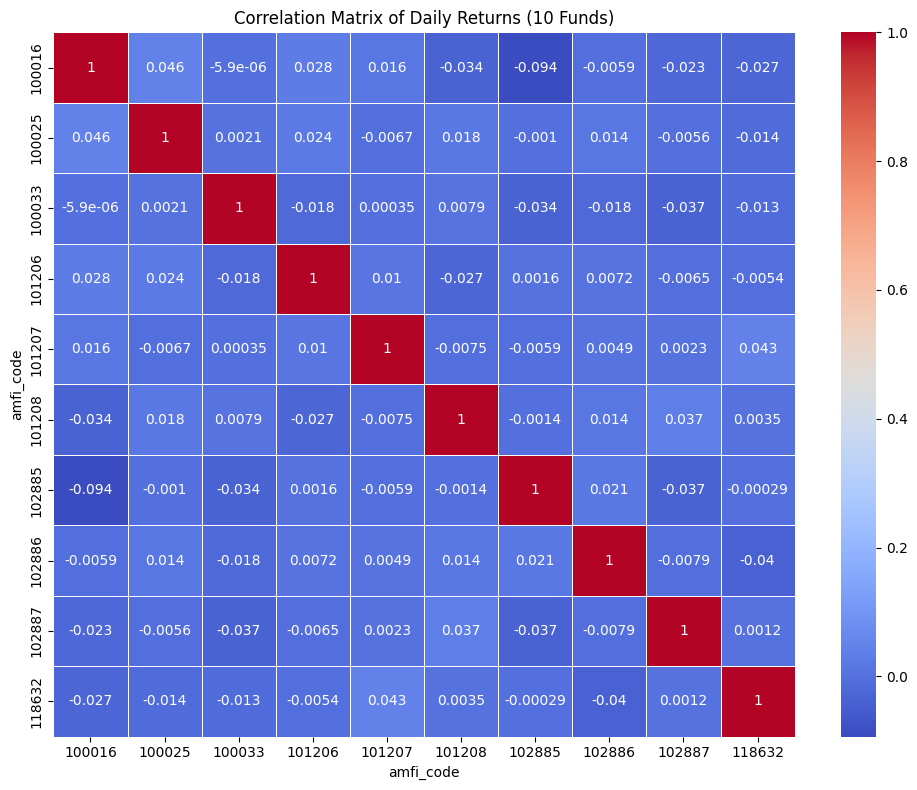

In [29]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily Returns (10 Funds)")

plt.tight_layout()

plt.savefig("../reports/charts/correlation_heatmap.png", dpi=300)

plt.show()

In [30]:
print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


# 12. Sector Allocation Across Equity Funds

This donut chart shows the overall sector allocation across all equity mutual funds based on portfolio holdings.

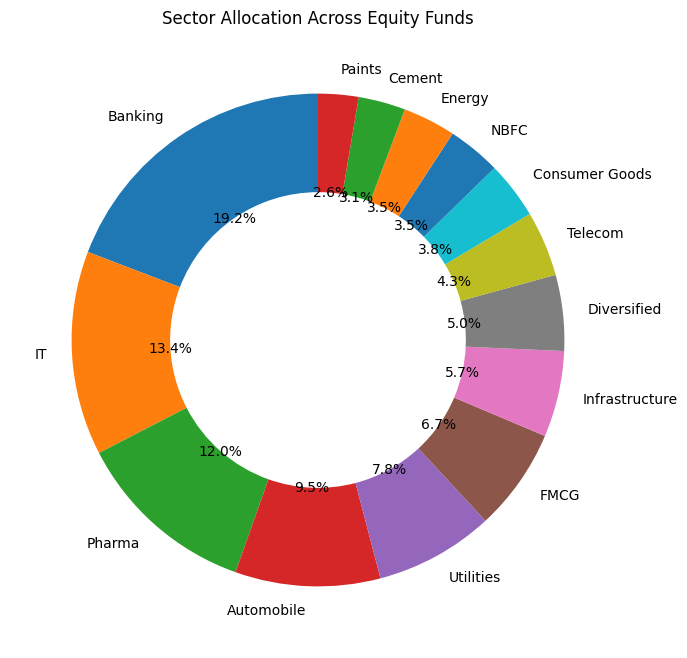

In [31]:
# Aggregate sector weights
sector = portfolio.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig("../reports/charts/sector_allocation.png", dpi=300)

plt.show()

# 13. Top 10 Stocks by Portfolio Weight

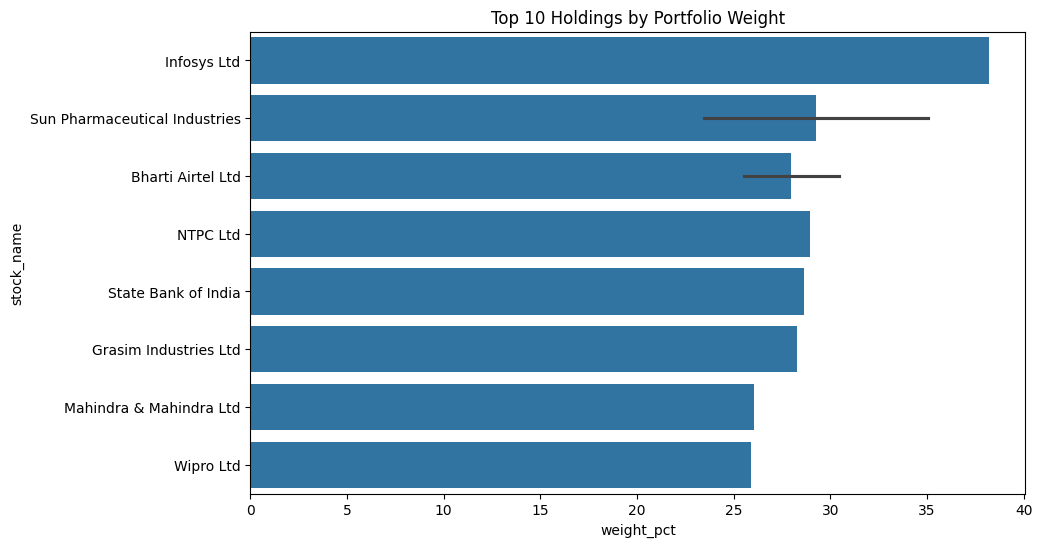

In [32]:
top10 = portfolio.sort_values(
    "weight_pct",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="weight_pct",
    y="stock_name"
)

plt.title("Top 10 Holdings by Portfolio Weight")

plt.savefig("../reports/charts/top10_holdings.png", dpi=300)

plt.show()

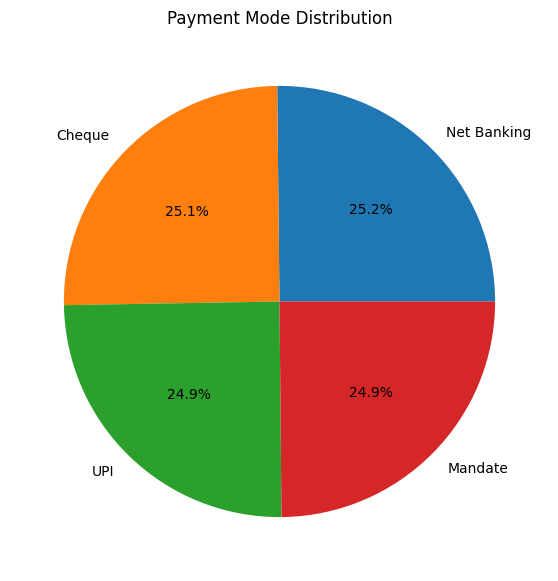

In [33]:
payment = transactions["payment_mode"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    payment,
    labels=payment.index,
    autopct="%1.1f%%"
)

plt.title("Payment Mode Distribution")

plt.savefig("../reports/charts/payment_mode.png", dpi=300)

plt.show()

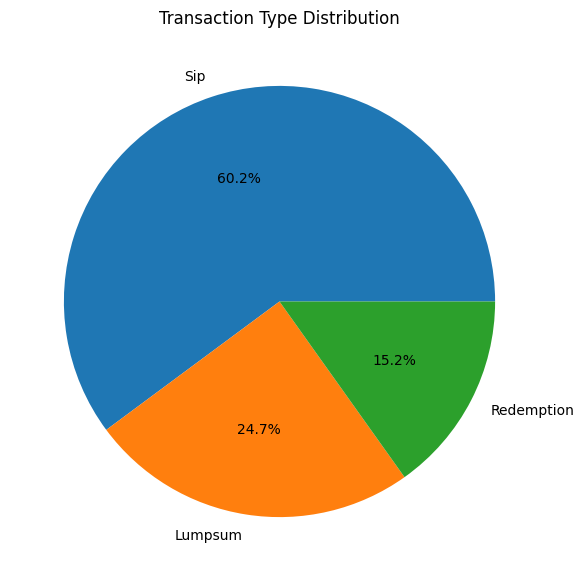

In [34]:
transaction = transactions["transaction_type"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    transaction,
    labels=transaction.index,
    autopct="%1.1f%%"
)

plt.title("Transaction Type Distribution")

plt.savefig("../reports/charts/transaction_type.png", dpi=300)

plt.show()

# Key EDA Findings

1. Daily NAVs showed an overall upward trend between 2022 and 2025.
2. A significant bull run was observed during 2023.
3. Market corrections were visible during 2024.
4. SBI Mutual Fund had the highest Assets Under Management, reaching ₹12.5 lakh crore.
5. SIP inflows increased consistently and reached an all-time high in December 2025.
6. Equity-oriented categories attracted the highest monthly inflows.
7. Investors in the 26–35 age group contributed the largest share of investments.
8. T30 cities accounted for a higher proportion of SIP investments than B30 cities.
9. Mutual fund folios nearly doubled between January 2022 and December 2025.
10. Technology, Banking, and Financial Services formed a significant portion of equity portfolios.